## Milestone 1.1

In [1]:
!nvidia-smi

Thu Apr  6 10:18:40 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 461.33       Driver Version: 461.33       CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  GeForce GTX 1060   WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   62C    P8     4W /  N/A |    206MiB /  6144MiB |      2%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

Your runtime has 17.0 gigabytes of available RAM



In [4]:
import requests
import pickle
import zipfile
import time
import os
#from google.colab import drive
import random
import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import asarray
from PIL.ImageStat import Stat
!pip install pydicom
import pydicom
# Package for converting PNG Files to DICOM(.dcm ) format
!pip install simpleitk
import SimpleITK as sitk
from sklearn.model_selection import train_test_split
from PIL import Image
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from tensorflow.keras.preprocessing.image import DataFrameIterator
from keras_preprocessing.image.dataframe_iterator import DataFrameIterator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense, Activation, MaxPool2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy

ModuleNotFoundError: No module named 'tensorflow'

In [5]:
data_path = './content'
archive_path = data_path + '/data/'
if os.path.exists(archive_path):
  print(f"{archive_path} directory exists.")
else:
  print(f"Did not find {archive_path} directory, creating one...")
  os.mkdir('./content')

  os.mkdir(archive_path)
  if os.path.exists(archive_path):
    print(f'{archive_path} created successfully')



Did not find ./content/data/ directory, creating one...
./content/data/ created successfully


In [20]:
import requests
import zipfile

In [35]:
def download_zip(filename, url):
    with open(filename, 'wb') as f:
        request = requests.get(url)
        print("Downloading requested data")
        f.write(request.content)
        print("Download completed")

In [51]:
COVID_ZIP = archive_path + 'CT_COVID.zip'
covid_url = 'https://github.com/UCSD-AI4H/COVID-CT/raw/master/Images-processed/CT_COVID.zip'
NON_COVID_ZIP = archive_path + 'CT_NonCOVID.zip'
non_covid_url = 'https://github.com/UCSD-AI4H/COVID-CT/raw/master/Images-processed/CT_NonCOVID.zip'

In [52]:
COVID_ZIP, NON_COVID_ZIP, covid_url, non_covid_url

('./content/data/CT_COVID.zip',
 './content/data/CT_NonCOVID.zip',
 'https://github.com/UCSD-AI4H/COVID-CT/raw/master/Images-processed/CT_COVID.zip',
 'https://github.com/UCSD-AI4H/COVID-CT/raw/master/Images-processed/CT_NonCOVID.zip')

In [53]:
download_zip(COVID_ZIP, covid_url)

Download completed


In [54]:
download_zip(NON_COVID_ZIP,non_covid_url )

Download completed


In [55]:
!ls -l  ./content/data

total 87908
-rw-r--r-- 1 shahe 197609 47929914 Apr  6 11:06 CT_COVID.zip
-rw-r--r-- 1 shahe 197609 42084013 Apr  6 11:06 CT_NonCOVID.zip
drwxr-xr-x 1 shahe 197609        0 Apr  6 11:02 __MACOSX


In [56]:
def unzip(archive_file, archive_path):
    with zipfile.ZipFile(archive_file, "r") as zip_ref:
        print("Unzipping archive") 
        zip_ref.extractall(archive_path)
        print("unzipped successfully")

In [57]:
unzip(COVID_ZIP, archive_path)

Unzipping archive
unzipped successfully


In [58]:
unzip(NON_COVID_ZIP, archive_path)

Unzipping archive
unzipped successfully


In [60]:
!ls ./content/data

CT_COVID
CT_COVID.zip
CT_NonCOVID
CT_NonCOVID.zip
__MACOSX


In [61]:
COVID_IMAGE_PATH = './content/data/CT_COVID/'
NON_COVID_IMAGE_PATH = './content/data/CT_NonCOVID/'

In [62]:
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [63]:
walk_through_dir(COVID_IMAGE_PATH)

There are 0 directories and 349 images in './content/data/CT_COVID/'.


In [64]:
walk_through_dir(NON_COVID_IMAGE_PATH)

There are 0 directories and 397 images in './content/data/CT_NonCOVID/'.


In [65]:

random.seed(42)

COVID_IMAGE_PATH_LIST = glob.glob(COVID_IMAGE_PATH + "/*.*")
len(COVID_IMAGE_PATH_LIST), type(COVID_IMAGE_PATH_LIST)

(349, list)

In [66]:
NON_COVID_IMAGE_PATH_LIST = glob.glob(NON_COVID_IMAGE_PATH + "/*.*")

len(NON_COVID_IMAGE_PATH_LIST), type(NON_COVID_IMAGE_PATH_LIST)

(397, list)

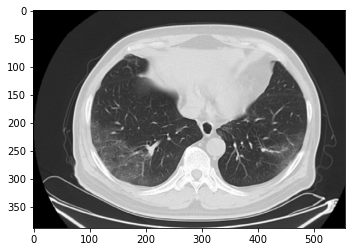

((388, 556, 3), PIL.PngImagePlugin.PngImageFile)

In [86]:
import matplotlib.pyplot as plt
random_image_cov = random.choice(COVID_IMAGE_PATH_LIST)
cov_pic = Image.open(random_image_cov)
plt.imshow(cov_pic)
plt.show()
#cov_pic.show()
np.array(cov_pic).shape, type(cov_pic)

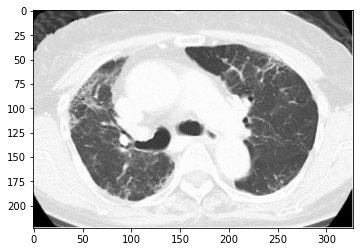

((223, 328, 3), PIL.JpegImagePlugin.JpegImageFile)

In [87]:
random_image_ncov = random.choice(NON_COVID_IMAGE_PATH_LIST)
ncov_pic = Image.open(random_image_ncov)
plt.imshow(ncov_pic)
plt.show()
#cov_pic.show()
np.array(ncov_pic).shape, type(ncov_pic)

In [109]:
def image_show(image_list, label):
  fig, subs = plt.subplots(3,3, figsize=(16,12))
  for i, sub in enumerate(subs.flatten()):
    #image_path = os.path.normpath(image[i])
    print(f'Image path is {image_list[i]} and label is {label}')
    img = Image.open(image_list[i])
    img.thumbnail((224,224))
    sub.imshow(img, cmap='gray')
    #sub.axis("off")
    print(f'Size of displayed image is {img.size}')
    sub.set_title(label)

In [110]:
random.seed(3)
ll_d_c =  []
for i in range(9):
  im = random.choice(COVID_IMAGE_PATH_LIST)
  ll_d_c.append(im)
print(ll_d_c, len(ll_d_c))

ll_d_nc = []
for i in range(9):
  im = random.choice(NON_COVID_IMAGE_PATH_LIST)
  ll_d_nc.append(im)

print(ll_d_nc, len(ll_d_nc))


['./content/data/CT_COVID\\2020.03.03.20030353-p17-106%1.png', './content/data/CT_COVID\\Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%4.png', './content/data/CT_COVID\\2020.03.26.20041426-p11-126.png', './content/data/CT_COVID\\2020.02.24.20027201-p19-670.png', './content/data/CT_COVID\\2020.03.12.20034686-p17-91-3.png', './content/data/CT_COVID\\ehaa254-p0-63%2.png', './content/data/CT_COVID\\2020.03.22.20034041-p17-80-1.png', './content/data/CT_COVID\\kjr-21-e25-p1-14.png', './content/data/CT_COVID\\Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%0.png'] 9
['./content/data/CT_NonCOVID\\11%1.jpg', './content/data/CT_NonCOVID\\63%7.jpg', './content/data/CT_NonCOVID\\10%2.jpg', './content/data/CT_NonCOVID\\414.png', './content/data/CT_NonCOVID\\1888.png', './content/data/CT_NonCOVID\\576.png', './content/data/CT_NonCOVID\\18%0.jpg', './content/data/CT_NonCOVID\\15%3.jpg', './content/data/CT_NonCOVID\\82.png'] 9


Image path is ./content/data/CT_COVID\2020.03.03.20030353-p17-106%1.png and label is COVID
Size of displayed image is (224, 157)
Image path is ./content/data/CT_COVID\Comparison-of-different-samples-for-2019-novel-cor_2020_International-Journa-p2-21%4.png and label is COVID
Size of displayed image is (211, 159)
Image path is ./content/data/CT_COVID\2020.03.26.20041426-p11-126.png and label is COVID
Size of displayed image is (224, 169)
Image path is ./content/data/CT_COVID\2020.02.24.20027201-p19-670.png and label is COVID
Size of displayed image is (224, 140)
Image path is ./content/data/CT_COVID\2020.03.12.20034686-p17-91-3.png and label is COVID
Size of displayed image is (224, 159)
Image path is ./content/data/CT_COVID\ehaa254-p0-63%2.png and label is COVID
Size of displayed image is (224, 191)
Image path is ./content/data/CT_COVID\2020.03.22.20034041-p17-80-1.png and label is COVID
Size of displayed image is (223, 224)
Image path is ./content/data/CT_COVID\kjr-21-e25-p1-14.png and

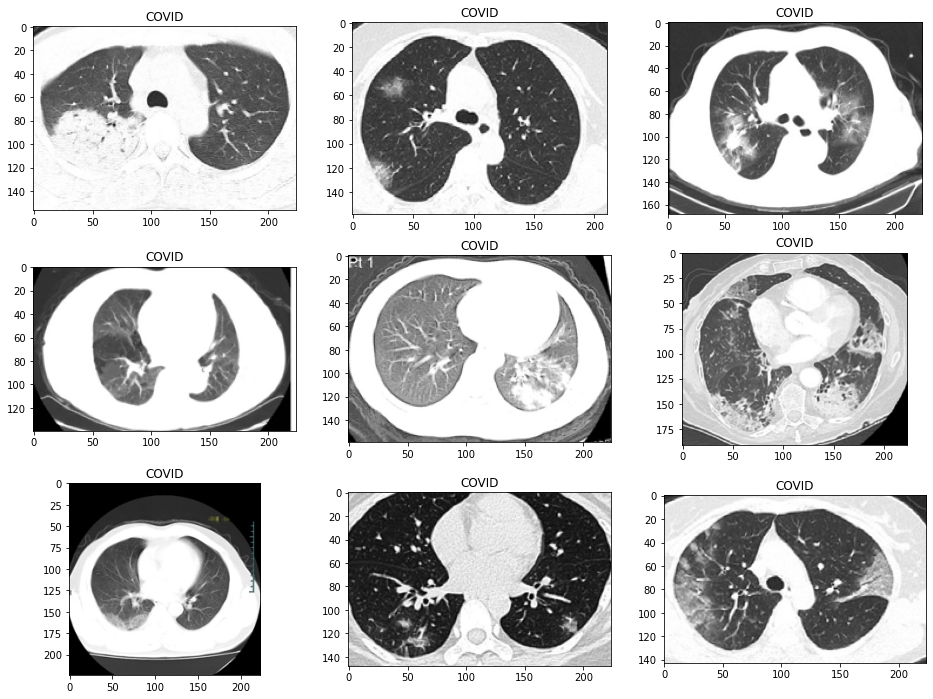

In [111]:
image_show(ll_d_c, 'COVID')

Image path is ./content/data/CT_NonCOVID\11%1.jpg and label is NON-COVID
Size of displayed image is (224, 186)
Image path is ./content/data/CT_NonCOVID\63%7.jpg and label is NON-COVID
Size of displayed image is (224, 150)
Image path is ./content/data/CT_NonCOVID\10%2.jpg and label is NON-COVID
Size of displayed image is (224, 187)
Image path is ./content/data/CT_NonCOVID\414.png and label is NON-COVID
Size of displayed image is (224, 144)
Image path is ./content/data/CT_NonCOVID\1888.png and label is NON-COVID
Size of displayed image is (224, 182)
Image path is ./content/data/CT_NonCOVID\576.png and label is NON-COVID
Size of displayed image is (224, 180)
Image path is ./content/data/CT_NonCOVID\18%0.jpg and label is NON-COVID
Size of displayed image is (224, 152)
Image path is ./content/data/CT_NonCOVID\15%3.jpg and label is NON-COVID
Size of displayed image is (224, 122)
Image path is ./content/data/CT_NonCOVID\82.png and label is NON-COVID
Size of displayed image is (224, 166)


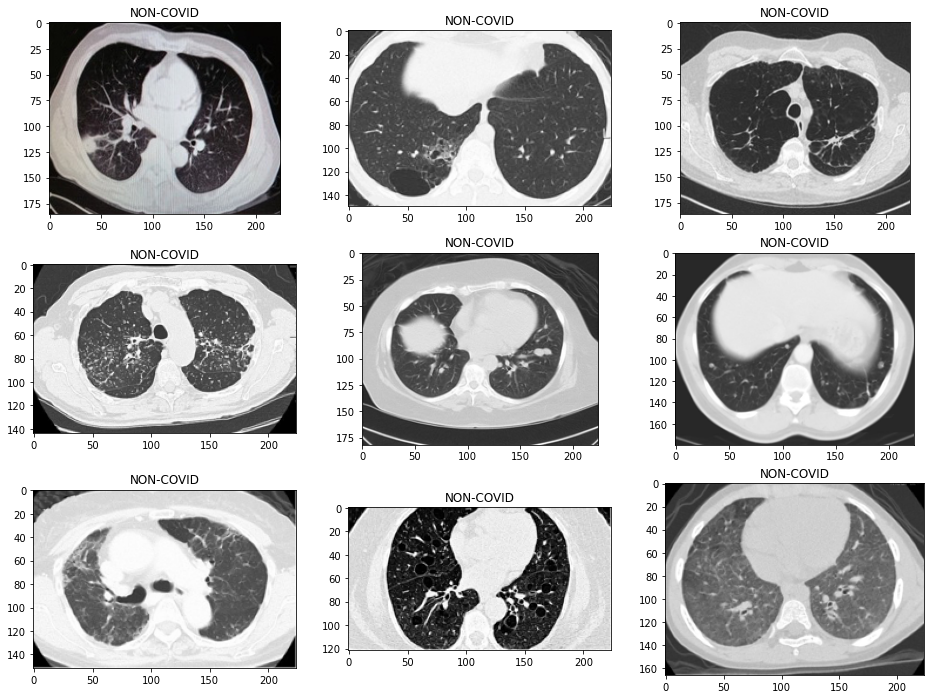

In [112]:
image_show(ll_d_nc, 'NON-COVID')

In [113]:
random_image = random.choice(COVID_IMAGE_PATH_LIST)
random_image_gs = Image.open(random_image).convert('L')
shape= random_image_gs.size
img= np.reshape(random_image_gs, (-1, *shape, 1))
img.shape  

(1, 406, 302, 1)

In [24]:
#def img_resize_save(img_path_list):
#  for i in range(len(img_path_list)):
#    temp_img = Image.open(img_path_list[i])
#    temp_img.thumbnail((224,224))
#    temp_img.save(img_path_list[i])
#  print('All images in supplied list resized to (224,224)')

#Originally I was under impression that all files have to be resized to 224,224 and then saved to disk. This is mentioned as a separate task.
#Hence, the logical deduction

In [114]:
df = pd.DataFrame({'Class': [len(NON_COVID_IMAGE_PATH_LIST), len(COVID_IMAGE_PATH_LIST)]})

In [115]:
total_class = df.Class.sum()
total_class

746

In [116]:
df['per_distr'] = df['Class'].apply(lambda x: x/total_class)
df.index = ['Non_Covid', 'Covid']

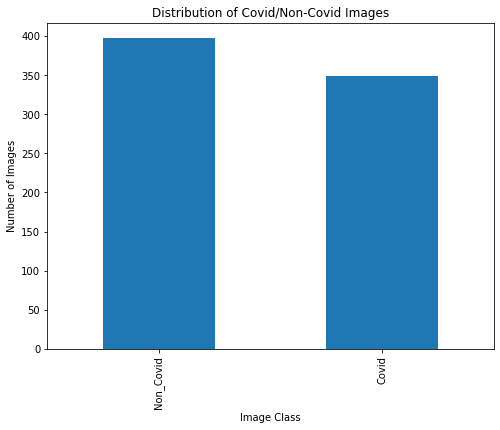

In [117]:
df.Class.plot(kind="bar", figsize=(8,6))
plt.ylabel("Number of Images")
plt.xlabel("Image Class")
plt.title("Distribution of Covid/Non-Covid Images")
plt.show()

In [134]:
list_arr = []
for pic in COVID_IMAGE_PATH_LIST:
    img = Image.open(pic).convert('L')
    img = img.resize((224,224))
    #img.thumbnail((224,224))
    pic_np = np.array(img)
    pic_np = pic_np.reshape(pic_np.shape[0],pic_np.shape[1],1)
    print(pic_np.shape)
    list_arr.append(pic_np)


(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 224, 1)
(224, 

In [135]:
len(list_arr)

349

In [137]:
covid_arr = np.array(list_arr)

In [138]:
np.mean(covid_arr), np.min(covid_arr), np.max(covid_arr), np.std(covid_arr)

(162.13826802434798, 0, 255, 83.30165119466977)

In [139]:
# Flatten the image data into a 1D array
pixel_values = covid_arr.flatten()

pixel_values.shape

(17511424,)

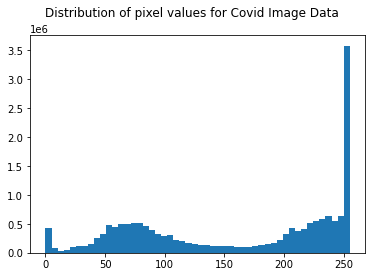

In [140]:
# Plot a histogram of the pixel values
plt.hist(pixel_values, bins=50)
plt.suptitle("Distribution of pixel values for Covid Image Data")
plt.show()

In [142]:
list_arr_nc = []
for pic in NON_COVID_IMAGE_PATH_LIST:
    img_nc = Image.open(pic).convert('L')
    img_nc = img_nc.resize((224,224))
    #img.thumbnail((224,224))
    pic_np_nc = np.array(img_nc)
    pic_np_nc = pic_np_nc.reshape(pic_np_nc.shape[0],pic_np_nc.shape[1],1)
    list_arr_nc.append(pic_np_nc)
len(list_arr_nc)

397

In [143]:
covid_arr_nc = np.array(list_arr_nc)
covid_arr_nc.shape


(397, 224, 224, 1)

In [145]:
np.min(covid_arr_nc), np.max(covid_arr_nc), np.mean(covid_arr_nc), np.std(covid_arr_nc)

(0, 255, 142.71773945133785, 82.72372265746586)

In [146]:
# Flatten the image data into a 1D array
pixel_values_nc = covid_arr_nc.flatten()
pixel_values_nc.shape

(19919872,)

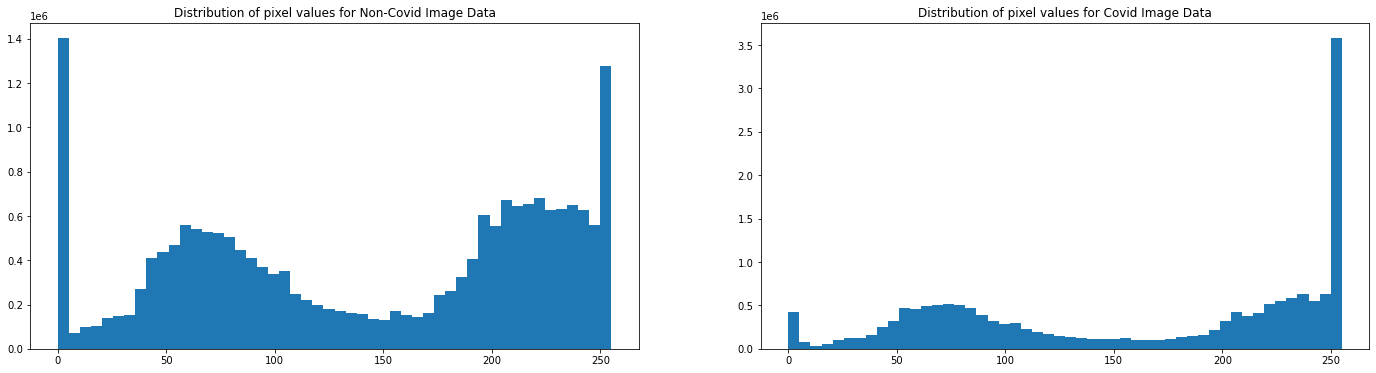

In [147]:
# Plot a histogram of the pixel values
fig, subs = plt.subplots(1,2, figsize=(24,6))
for i, sub in enumerate(subs.flatten()):
  if i==0:
    sub.hist(pixel_values_nc, bins=50)
    sub.set_title("Distribution of pixel values for Non-Covid Image Data")
  else:
    sub.hist(pixel_values, bins=50)
    sub.set_title("Distribution of pixel values for Covid Image Data")




In [161]:
#Lets do simple check on whether the pixel data that we get from converted .dcm files is same what we get from original png image
image = COVID_IMAGE_PATH_LIST[0]
im1 = Image.open(image).convert('L')
im1= np.array(im1)
img= sitk.GetImageFromArray(im1)
sitk.WriteImage(img,'template.dcm')
    

<class 'numpy.ndarray'> (335, 580)


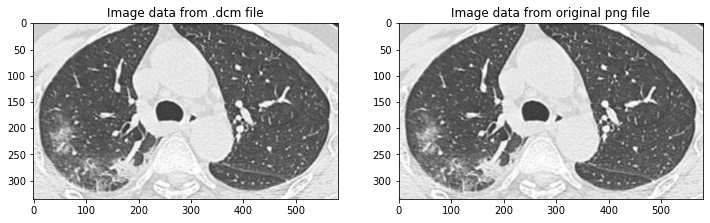

In [211]:
fig, subs = plt.subplots(1,2, figsize=(12,6))
for i, sub in enumerate(subs.flatten()):
  if i==0:
    #ds = pydicom.dcmread('template.dcm')
    # Load the DICOM file
    ds = pydicom.dcmread('template.dcm')
    # Access the image data
    image_d = ds.pixel_array
    print(type(image_d), np.array(image_d).shape)
    sub.imshow(image_d, cmap='gray')
    sub.set_title("Image data from .dcm file")
  else:
    sub.imshow(im1, cmap='gray')
    sub.set_title("Image data from original png file")

## It does looks like the data from both sources are one and same. 
## STATUS : VERIFIED

## Convert all the PNG Files to DICOM (.dcm) Format

In [163]:
DCM_FILE_PATH = './content/data/DCM/'
COVID_DCM_FILE_PATH = './content/data/DCM/COVID/'
NON_COVID_DCM_FILE_PATH = './content/data/DCM/NON_COVID/'
if os.path.exists(DCM_FILE_PATH):
  print(f"{DCM_FILE_PATH} directory exists.")
  if os.path.exists(COVID_DCM_FILE_PATH):
    print(f'{COVID_DCM_FILE_PATH} directory exists')
  else:
    print(f'Ok... looks like {COVID_DCM_FILE_PATH} does not exists. Let us make one')
    os.mkdir(COVID_DCM_FILE_PATH)
    print(f'{COVID_DCM_FILE_PATH} directory created successfully')
  if os.path.exists(NON_COVID_DCM_FILE_PATH):
    print(f'{NON_COVID_DCM_FILE_PATH} directory exists')
  else:
    print(f'Ok... looks like {NON_COVID_DCM_FILE_PATH} does not exists. Let us make one')
    os.mkdir(NON_COVID_DCM_FILE_PATH)
    print(f'{NON_COVID_DCM_FILE_PATH} directory created successfully')
else:
  print(f'Looks like there is no directory structure below /content/data.. Lets create required directory structures')
  print(f'Creating {DCM_FILE_PATH} directory path first')
  os.mkdir(DCM_FILE_PATH)
  print(f'{DCM_FILE_PATH} directory created successfully')

  print(f'Creating {COVID_DCM_FILE_PATH} directory path')
  os.mkdir(COVID_DCM_FILE_PATH)
  print(f'{COVID_DCM_FILE_PATH} directory created successfully')

  print(f'Creating {NON_COVID_DCM_FILE_PATH} directory path')
  os.mkdir(NON_COVID_DCM_FILE_PATH)
  print(f'{NON_COVID_DCM_FILE_PATH} directory created successfully')



Looks like there is no directory structure below /content/data.. Lets create required directory structures
Creating ./content/data/DCM/ directory path first
./content/data/DCM/ directory created successfully
Creating ./content/data/DCM/COVID/ directory path
./content/data/DCM/COVID/ directory created successfully
Creating ./content/data/DCM/NON_COVID/ directory path
./content/data/DCM/NON_COVID/ directory created successfully


In [169]:

def pngtodcm(image_list, COVID, l_i):
    print(f'COVID variable is set to {COVID}')
    list_im = []
    list_im = l_i

    for i, png_image in enumerate(image_list):
        png_im_arr = np.array(Image.open(png_image).convert('L'))
        dcm_im_arr = sitk.GetImageFromArray(png_im_arr)
        i = str(i)
        if COVID:
            SAVE_PATH = COVID_DCM_FILE_PATH
            list_im = list_im_c
            FILENAME = "COVID_" + i
        else:
            SAVE_PATH = NON_COVID_DCM_FILE_PATH
            list_im = list_im_nc
            FILENAME = "NON_COVID_" + i
        DCM_FILENAME = SAVE_PATH + FILENAME + '.dcm'
        sitk.WriteImage(dcm_im_arr, DCM_FILENAME)
        print(f'Successfully converted and saved {DCM_FILENAME}')
        list_im.append(DCM_FILENAME)




In [170]:
list_im_c = []
pngtodcm(COVID_IMAGE_PATH_LIST, True, list_im_c)

COVID variable is set to True
Successfully converted and saved ./content/data/DCM/COVID/COVID_0.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_1.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_2.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_3.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_4.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_5.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_6.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_7.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_8.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_9.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_10.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_11.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_12.dcm
Successfully converted and saved ./content/data/DCM/COVID

Successfully converted and saved ./content/data/DCM/COVID/COVID_126.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_127.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_128.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_129.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_130.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_131.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_132.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_133.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_134.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_135.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_136.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_137.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_138.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_

Successfully converted and saved ./content/data/DCM/COVID/COVID_261.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_262.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_263.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_264.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_265.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_266.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_267.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_268.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_269.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_270.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_271.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_272.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_273.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID_

In [171]:
len(list_im_c)

349

In [172]:
list_im_nc = []
pngtodcm(NON_COVID_IMAGE_PATH_LIST, False, list_im_nc)

COVID variable is set to False
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_0.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_1.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_2.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_3.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_4.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_5.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_6.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_7.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_8.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_9.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_10.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_11.dcm
Successfully converted and save

Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_110.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_111.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_112.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_113.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_114.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_115.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_116.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_117.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_118.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_119.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_120.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_121.dcm
Successfully converted and saved ./conte

Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_244.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_245.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_246.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_247.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_248.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_249.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_250.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_251.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_252.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_253.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_254.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_255.dcm
Successfully converted and saved ./conte

Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_376.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_377.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_378.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_379.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_380.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_381.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_382.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_383.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_384.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_385.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_386.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/NON_COVID_387.dcm
Successfully converted and saved ./conte

In [173]:
len(list_im_nc), len(list_im_c)

(397, 349)

In [174]:
len(NON_COVID_IMAGE_PATH_LIST), len(COVID_IMAGE_PATH_LIST)

(397, 349)

In [175]:
list_im_nc[0], list_im_c[0]

('./content/data/DCM/NON_COVID/NON_COVID_0.dcm',
 './content/data/DCM/COVID/COVID_0.dcm')

In [176]:
def extract_fnames(file_list):
  temp_ll = []
  for i in file_list:
    fname = i.split("/")[-1].split(".")[0]
    temp_ll.append(fname)
    return sorted(temp_ll)

In [177]:
ll_dc_fname = extract_fnames(list_im_c)
ll_dnc_fname = extract_fnames(list_im_nc)
ll_pc_fname = extract_fnames(COVID_IMAGE_PATH_LIST)
ll_pnc_fname = extract_fnames(NON_COVID_IMAGE_PATH_LIST)



In [180]:
df_nc = pd.DataFrame()

In [181]:
df_nc['filename'] = list_im_nc

In [182]:
df_nc['class'] = 0

In [183]:
df_nc

,filename,class
0,./content/data/DCM/NON_COVID/NON_COVID_0.dcm,0
1,./content/data/DCM/NON_COVID/NON_COVID_1.dcm,0
2,./content/data/DCM/NON_COVID/NON_COVID_2.dcm,0
3,./content/data/DCM/NON_COVID/NON_COVID_3.dcm,0
4,./content/data/DCM/NON_COVID/NON_COVID_4.dcm,0
...,...,...
392,./content/data/DCM/NON_COVID/NON_COVID_392.dcm,0
393,./content/data/DCM/NON_COVID/NON_COVID_393.dcm,0
394,./content/data/DCM/NON_COVID/NON_COVID_394.dcm,0
395,./content/data/DCM/NON_COVID/NON_COVID_395.dcm,0


In [184]:
label_1 = list(np.ones(len(list_im_c), dtype=int))
len(label_1), len(list_im_c)

(349, 349)

In [185]:
dict_c = {'filename': list_im_c, 'class': label_1}

In [186]:
df_c = pd.DataFrame(data=dict_c)

In [187]:
df_c

,filename,class
0,./content/data/DCM/COVID/COVID_0.dcm,1
1,./content/data/DCM/COVID/COVID_1.dcm,1
2,./content/data/DCM/COVID/COVID_2.dcm,1
3,./content/data/DCM/COVID/COVID_3.dcm,1
4,./content/data/DCM/COVID/COVID_4.dcm,1
...,...,...
344,./content/data/DCM/COVID/COVID_344.dcm,1
345,./content/data/DCM/COVID/COVID_345.dcm,1
346,./content/data/DCM/COVID/COVID_346.dcm,1
347,./content/data/DCM/COVID/COVID_347.dcm,1


In [190]:
df = pd.concat([df_nc, df_c])

In [191]:
df.reset_index(inplace=True, drop=True)

In [193]:
df

,filename,class
0,./content/data/DCM/NON_COVID/NON_COVID_0.dcm,0
1,./content/data/DCM/NON_COVID/NON_COVID_1.dcm,0
2,./content/data/DCM/NON_COVID/NON_COVID_2.dcm,0
3,./content/data/DCM/NON_COVID/NON_COVID_3.dcm,0
4,./content/data/DCM/NON_COVID/NON_COVID_4.dcm,0
...,...,...
741,./content/data/DCM/COVID/COVID_344.dcm,1
742,./content/data/DCM/COVID/COVID_345.dcm,1
743,./content/data/DCM/COVID/COVID_346.dcm,1
744,./content/data/DCM/COVID/COVID_347.dcm,1


In [194]:
df['class'].value_counts()

0    397
1    349
Name: class, dtype: int64

In [195]:
df.to_csv('./content/data/DCM/CT_dcm_files_list_labels.csv', index=False)

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  746 non-null    object
 1   class     746 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.8+ KB


## Milestone 1.2

In [197]:
df_loaddata = pd.read_csv('./content/data/DCM/CT_dcm_files_list_labels.csv')

In [198]:
df_loaddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746 entries, 0 to 745
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  746 non-null    object
 1   class     746 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.8+ KB


In [199]:
len(df_loaddata.filename.unique())

746

In [200]:
df_loaddata['class'].value_counts()

0    397
1    349
Name: class, dtype: int64

In [202]:
df_X = df_loaddata.drop(columns=['class'])
df_y = df_loaddata['class']

In [203]:
df_y.head(), df_X.head()

(0    0
 1    0
 2    0
 3    0
 4    0
 Name: class, dtype: int64,
                                        filename
 0  ./content/data/DCM/NON_COVID/NON_COVID_0.dcm
 1  ./content/data/DCM/NON_COVID/NON_COVID_1.dcm
 2  ./content/data/DCM/NON_COVID/NON_COVID_2.dcm
 3  ./content/data/DCM/NON_COVID/NON_COVID_3.dcm
 4  ./content/data/DCM/NON_COVID/NON_COVID_4.dcm)

In [204]:
train_df, test_df = train_test_split(df_loaddata, test_size=0.2, random_state=42, stratify=df['class'])

len(train_df), len(test_df)

(596, 150)

In [205]:
# we need to further reserve 20% data in training for validation
train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['class'])

len(train_df), len(valid_df)

(476, 120)

In [206]:
train_df['class'].sum(), valid_df['class'].sum(), test_df['class'].sum()

(223, 56, 70)

In [207]:
train_df['class'].sum() + valid_df['class'].sum() + test_df['class'].sum()

349

In [208]:
train_aug_params = dict(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range = [0.8, 1.2]
)

valid_aug_params = dict(
    rescale=1./255
    )

test_aug_params = dict(
    rescale=1./255
)


In [209]:
#Creating augmenters

train_augmenter = ImageDataGenerator(**train_aug_params)
valid_augmenter = ImageDataGenerator(**valid_aug_params)
test_augmenter = ImageDataGenerator(**test_aug_params)

NameError: name 'ImageDataGenerator' is not defined

In [138]:
type(train_augmenter), type(valid_augmenter), type(test_augmenter)

(tensorflow.python.keras.preprocessing.image.ImageDataGenerator,
 tensorflow.python.keras.preprocessing.image.ImageDataGenerator,
 tensorflow.python.keras.preprocessing.image.ImageDataGenerator)

In [139]:
# training parameters
BATCH_SIZE = 32
COLOR_MODE = 'grayscale'
TARGET_SIZE = (224, 224)
EPOCHS = 10

train_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE,  
}

valid_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE, 
    'shuffle': False
}

test_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE,  # resize input images
    'shuffle': False
}


In [140]:
class DCMDataFrameIterator(DataFrameIterator):
    def __init__(self, *arg, **kwargs):
        self.white_list_formats = ('dcm')
        super(DCMDataFrameIterator, self).__init__(*arg, **kwargs)
        self.dataframe = kwargs['dataframe']
        self.x = self.dataframe[kwargs['x_col']]
        self.y = self.dataframe[kwargs['y_col']]
        self.color_mode = kwargs['color_mode']
        self.target_size = kwargs['target_size']

    def _get_batches_of_transformed_samples(self, indices_array):
        # get batch of images
        batch_x = np.array([self.read_dcm_as_array(dcm_path, self.target_size, color_mode=self.color_mode)
                            for dcm_path in self.x.iloc[indices_array]])

        batch_y = np.array(self.y.iloc[indices_array].astype(np.uint8))  # astype because y was passed as str

        # transform images
        if self.image_data_generator is not None:
            for i, (x, y) in enumerate(zip(batch_x, batch_y)):
                transform_params = self.image_data_generator.get_random_transform(x.shape)
                batch_x[i] = self.image_data_generator.apply_transform(x, transform_params)
                
                # you can change y here as well, eg: in semantic segmentation you want to transform masks as well 
                # using the same image_data_generator transformations.

        return batch_x, batch_y

    @staticmethod
    def read_dcm_as_array(dcm_path, target_size=(256, 256), color_mode='rgb'):
        image_array = pydicom.dcmread(dcm_path).pixel_array
        image = Image.fromarray(image_array) #converts from array to PIL
        #image = Image.open(image).convert('L')
        image.thumbnail((224,224)) #resize image to 224,224
        #image_array = cv2.resize(image_array, target_size, interpolation=cv2.INTER_NEAREST)  #this returns a 2d array
        image_array = np.expand_dims(image, -1)
        return image_array.astype(np.float32)

In [141]:
train_df['class'] = train_df['class'].astype('str')
valid_df['class'] = valid_df['class'].astype('str')
test_df['class'] = test_df['class'].astype('str')

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [142]:
train_df.info(), valid_df.info(),  test_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8836 entries, 13528 to 8134
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  8836 non-null   object
 1   class     8836 non-null   object
dtypes: object(2)
memory usage: 207.1+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2210 entries, 6681 to 12452
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2210 non-null   object
 1   class     2210 non-null   object
dtypes: object(2)
memory usage: 51.8+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2762 entries, 1939 to 8436
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2762 non-null   object
 1   class     2762 non-null   object
dtypes: object(2)
memory usage: 64.7+ KB


(None, None, None)

In [143]:
train_generator = DCMDataFrameIterator(dataframe=train_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=train_augmenter,
                             **train_consts)

valid_generator = DCMDataFrameIterator(dataframe=valid_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=valid_augmenter,
                             **valid_consts)

test_generator = DCMDataFrameIterator(dataframe=test_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=test_augmenter,
                             **test_consts)

Found 8836 validated image filenames belonging to 2 classes.
Found 2210 validated image filenames belonging to 2 classes.
Found 2762 validated image filenames belonging to 2 classes.


In [144]:
#train_augmenter.fit(train_generator)

In [145]:
classes = ['NON-COVID', 'COVID']

In [146]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(train_generator))

imgs.shape, labels.shape, type(imgs), type(labels)

((32, 224, 224, 1), (32,), numpy.ndarray, numpy.ndarray)

In [147]:
imgs[0].mean(), imgs[0].max(), imgs[0].min()

(132.79631, 255.0, 0.0)

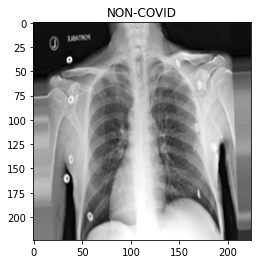

In [148]:
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

(32, 224, 224, 1) (32,) <class 'numpy.ndarray'> <class 'numpy.ndarray'>


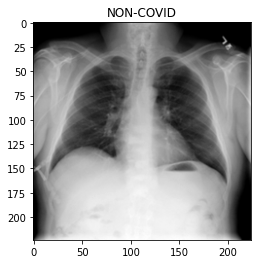

In [149]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(valid_generator))
print(imgs.shape, labels.shape, type(imgs), type(labels))
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

(32, 224, 224, 1) (32,) <class 'numpy.ndarray'> <class 'numpy.ndarray'>


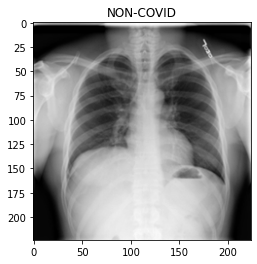

In [150]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(test_generator))
print(imgs.shape, labels.shape, type(imgs), type(labels))
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

In [151]:
imgs[0].dtype

dtype('float32')

In [152]:
#imgs[0]

In [153]:
#help(train_generator)

In [154]:
import tensorflow

In [155]:
class VGG16_custom(tensorflow.keras.Model):
    def __init__(self, input_dim):
        super(VGG16_custom, self).__init__()
        
        self.conv_block_1 = Sequential(self.create_conv_block(64, 2, True))
        self.conv_block_2 = Sequential(self.create_conv_block(128, 2, True))
        self.conv_block_3 = Sequential(self.create_conv_block(256, 3, True))
        self.conv_block_4 = Sequential(self.create_conv_block(512, 3, True))
        self.conv_block_5 = Sequential(self.create_conv_block(512, 3, True))
        
        self.intermediate = Sequential([
            Flatten(),
            Dropout(0.01),
            Dense(4096, use_bias=False),
            BatchNormalization(),
            Activation('relu'),
            Dropout(0.5),
            Dense(4096, use_bias=False),
            BatchNormalization(),
            Activation('relu'),
            Dropout(0.5)
        ]
        )
    
        self.classifier = Dense(2)
    
    
#############################################################################        
    def create_conv_block(self,out_dim, instances, batch_norm):
        ll = []
        for i in range(instances):
            layer = self.create_layer(out_dim, batch_norm)
            ll.extend(layer)
        maxpool = MaxPool2D((2,2), strides=(2,2))
        ll.append(maxpool)
        return ll
        
    def create_layer(self,out_dim, batch_norm):
        layer_list = []
        if batch_norm:
            flag = False
        else:
            flag = True
        layer = Conv2D(out_dim, (3,3), padding='same', use_bias=flag)
        layer_list.append(layer)
        if batch_norm:
            bn = BatchNormalization()
            layer_list.append(bn)
        activation = Activation('relu')
        layer_list.append(activation)
        return layer_list  

    def call(self, input_dim):
        x = self.conv_block_1(input_dim)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.conv_block_4(x)
        x = self.conv_block_5(x)
        x = self.intermediate(x)
        x = self.classifier(x)

        return x
    

In [156]:
#VGG16_custom(224).build([None, 224,244,1,])
X_input = Input(shape=(224,224,1,))
out = VGG16_custom(224)(X_input)
temp_model = Model(inputs=X_input, outputs=out)
temp_model.summary()#expand_nested=True)

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 224, 224, 1)]     0         
_________________________________________________________________
vg_g16_custom_2 (VGG16_custo (None, 2)                 134304834 
Total params: 134,304,834
Trainable params: 134,280,002
Non-trainable params: 24,832
_________________________________________________________________


In [157]:
model_vgg16 = VGG16_custom(224)

In [158]:
#help(tensorflow.python.keras.layers.convolutional.Conv2D)

In [159]:
#model_vgg16.get_layer(0)
for layer in model_vgg16.layers:
    for sub_layer in layer.layers:
        config = sub_layer.get_config()
        if config['name'].__contains__('conv2d'):
            print(f'{config["name"]}, {config["filters"]}, {config["kernel_size"]}, {config["strides"]}, {config["padding"]}, {config["use_bias"]}')
        elif config['name'].__contains__('batch_normalization'):
            print(f'{config["name"]}')
        elif config['name'].__contains__('activation'):
            print(f'{config["name"]}, {config["activation"]}')
        elif config['name'].__contains__('max_pooling2d'):
            print(f'{config["name"]}, {config["pool_size"]}, {config["strides"]}')
            
                  
                  

conv2d_39, 64, (3, 3), (1, 1), same, False
batch_normalization_45
activation_45, relu
conv2d_40, 64, (3, 3), (1, 1), same, False
batch_normalization_46
activation_46, relu
max_pooling2d_15, (2, 2), (2, 2)
conv2d_41, 128, (3, 3), (1, 1), same, False
batch_normalization_47
activation_47, relu
conv2d_42, 128, (3, 3), (1, 1), same, False
batch_normalization_48
activation_48, relu
max_pooling2d_16, (2, 2), (2, 2)
conv2d_43, 256, (3, 3), (1, 1), same, False
batch_normalization_49
activation_49, relu
conv2d_44, 256, (3, 3), (1, 1), same, False
batch_normalization_50
activation_50, relu
conv2d_45, 256, (3, 3), (1, 1), same, False
batch_normalization_51
activation_51, relu
max_pooling2d_17, (2, 2), (2, 2)
conv2d_46, 512, (3, 3), (1, 1), same, False
batch_normalization_52
activation_52, relu
conv2d_47, 512, (3, 3), (1, 1), same, False
batch_normalization_53
activation_53, relu
conv2d_48, 512, (3, 3), (1, 1), same, False
batch_normalization_54
activation_54, relu
max_pooling2d_18, (2, 2), (2, 2)


AttributeError: 'Dense' object has no attribute 'layers'

In [160]:
opt = Adam(learning_rate=0.0001)
loss_fn = tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [161]:
train_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()
test_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()


In [162]:
from sklearn.metrics import confusion_matrix

In [163]:
os.mkdir('./content/data/ckpt')
os.mkdir('./content/data/saved_model')

In [164]:
class Model_Train():
    def __init__(self, model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen, train_acc_metric, val_acc_metric, test_acc_metric):
        super().__init__()

        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.train_generator = train_gen
        self.valid_generator = valid_gen
        self.test_generator = test_gen
        self.steps_train = len(train_gen)
        self.steps_valid = len(valid_gen)
        self.steps_test = len(test_gen)
        self.train_acc_metric = train_acc_metric
        self.val_acc_metric = val_acc_metric
        self.test_acc_metric = test_acc_metric
        self.train_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': []}
        self.valid_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'ckpt_name': []}


   

    @tensorflow.function
    def train_step(self, train_data, train_label):
        with tensorflow.GradientTape() as tape:
            output = self.model(train_data, training=True)
            loss_value = self.loss_fn(train_label, output)
        grads = tape.gradient(loss_value, self.model.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_weights))
        self.train_acc_metric.update_state(train_label, output)
        return output, loss_value

    @tensorflow.function
    def test_step(self, validation_data, validation_label):
        val_output = self.model(validation_data, training=False)
        loss_value = self.loss_fn(validation_label, val_output)
        self.val_acc_metric.update_state(validation_label, val_output)
        return val_output, loss_value

    def getloss_accuracy(self, gen, batch_size, steps_per_epoch, df, train=False):
        loss_epoch = 0
        for step, (x_batch, y_batch) in enumerate(gen):
            if train:
                output, loss_value = self.train_step(x_batch, y_batch)
        ###new code below
        
                pred_labls = list(np.argmax(output.numpy(), axis=1))
                temp_df = pd.DataFrame({'orig_label': list(y_batch), 'pred_label': pred_labls})
                df = pd.concat([df, temp_df])
            

        ## newcode above
        
            else:
                output, loss_value = self.test_step(x_batch, y_batch)
                pred_labls = list(np.argmax(output.numpy(), axis=1))
                temp_df = pd.DataFrame({'orig_label': list(y_batch), 'pred_label': pred_labls})
                df = pd.concat([df, temp_df])
            
            loss_epoch += loss_value*self.batch_size
            if step >= steps_per_epoch:
                avg_epoch_loss = (loss_epoch/((step+1)*self.batch_size)).numpy()
                if train:
                    accuracy = self.train_acc_metric.result().numpy()
                    self.train_acc_metric.reset_states()
                    gen.on_epoch_end()
                else:
                    accuracy = self.val_acc_metric.result().numpy()
                    self.val_acc_metric.reset_states()


                return df, avg_epoch_loss, accuracy

    def train_validate_loop(self):
        for epoch in range(self.epochs):
            start_time = time.time()
            histdf_train = pd.DataFrame({'orig_label': [], 'pred_label': []})
            histdf_val   = pd.DataFrame({'orig_label': [], 'pred_label': []})  

            df_train_cm, avg_epoch_train_loss, train_accuracy = self.getloss_accuracy(self.train_generator, self.batch_size, self.steps_train, histdf_train, train=True)
            df_val_cm, avg_epoch_val_loss, val_accuracy = self.getloss_accuracy(self.valid_generator, self.batch_size, self.steps_valid, histdf_val, train=False)

    
            f1, precision, recall             = self.calc_rec_prec_f1(df_train_cm, train=True)
            f1_val, precision_val, recall_val = self.calc_rec_prec_f1(df_val_cm, train=False)


            print(f'Epoch : {epoch}, Train Loss: {avg_epoch_train_loss}, Train Accuracy: {train_accuracy}, Validation Loss: {avg_epoch_val_loss}, Validation Accuracy: {val_accuracy}')
      
            self.train_history['loss'].append(avg_epoch_train_loss)
            self.train_history['accuracy'].append(train_accuracy)
            self.train_history['f1'].append(f1)
            self.train_history['precision'].append(precision)
            self.train_history['recall'].append(recall)

            self.valid_history['loss'].append(avg_epoch_val_loss)
            self.valid_history['accuracy'].append(val_accuracy)
            self.valid_history['f1'].append(f1_val)
            self.valid_history['precision'].append(precision_val)
            self.valid_history['recall'].append(recall_val)

      ###New Code for early stopping#####
            la = self.valid_history['accuracy']
            if (len(la) > 4):
                if (((la[-1] <= la[-2]) and (la[-2] <= la[-3])) and ((la[-3] <= la[-4]) and (la[-4] <= la[-5]))):
                    print("Validation accuracy has not improved over last 4 epochs, hence invoking early stopping and exiting training process")
                    print('Loading Best weights..')
                    self.model.load_weights(self.valid_history['ckpt_name'][-1])
                    break
            if ((la[-1] > 0.9) and (la[-1] > max(la[0:-1]))):
                ckpt_name = './content/data/ckpt/' + 'ckpt' + '_' + str(la[-1]) + '_acc.pt'
                pb_name = './content/data/saved_model/' + 'ckpt' + '_' + str(la[-1]) + '_acc'
                self.model.save_weights(ckpt_name)
                self.valid_history['ckpt_name'].append(ckpt_name)
                print(f'Saved Checkpoint : {ckpt_name}')
                self.model.save(pb_name)
                print(f'Saved model in protobuf format : {pb_name}')




      #####New Cod for early stopping


    
            print(f'Time taken: {np.round((time.time() - start_time), 4)}')
        print(f'Training completed successfully. Loading best checkpoint weights ...')
        self.model.load_weights(self.valid_history['ckpt_name'][-1])
        print(f'Best checkpoint weights loaded : {self.valid_history["ckpt_name"][-1]}')

      #draw graph depicting train and validation losses and accuracy + recall, f1
        return self.train_history, self.valid_history

    def get_test_accuracy(self):
        df = pd.DataFrame({'orig_label': [], 'pred_label': []})
        df_test, avg_test_loss, test_accuracy = self.getloss_accuracy(self.test_generator, self.batch_size, self.steps_test, df, train=False)
        return df_test, avg_test_loss, test_accuracy

    def calc_rec_prec_f1(self, df, train):
        print_string = "Training Confusion Matrix" if train else "Validation Confusion Matrix"
        print(print_string, "\n", confusion_matrix(df['orig_label'], df['pred_label']))
        tn, fp, fn, tp = confusion_matrix(df['orig_label'], df['pred_label']).ravel()
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1 = 2*precision*recall/(precision+recall)
        return f1, precision, recall

    def predict_single(self,dcm_path, target_size=(224,224)):
        image_array = pydicom.dcmread(dcm_path).pixel_array
        image = Image.fromarray(image_array) #converts from array to PIL
        image.thumbnail((224,224)) #resize image to 224,224
        image_array = np.expand_dims(image, -1)
        image_array = image_array.astype(np.float32) # * (1.0/255.0)
        image_array = np.expand_dims(image_array, 0)
        output = self.model(image_array, training=False)
        pred_label = np.argmax(output.numpy())
        print(f'Predicted label for image supplied is : {classes[pred_label]}')
        return classes[pred_label]
    
    def pred_image_show(self,image_list):
        fig, subs = plt.subplots(3,3, figsize=(14,12))
        for i, sub in enumerate(subs.flatten()):
            print(f'Image path is {image_list[i][0]} and Original label is {classes[int(image_list[i][1])]}')
            pred_class = self.predict_single(image_list[i][0])
            image_array = pydicom.dcmread(image_list[i][0]).pixel_array
            sub.imshow(image_array, cmap='gray')
            sub.set_title(f'{pred_class}(Pred) : {classes[int(image_list[i][1])]}(Orig)')
            
    def plot_metrics(self):
        list = ['accuracy', 'loss', 'f1', 'recall', 'precision']
        for metrics in list:
            x = [i for i in range(len(self.train_history[metrics]))]
            y1 = self.train_history[metrics]
            y2 = self.valid_history[metrics]
            fig, ax = plt.subplots()
            ax.plot(x, y1, label="train_"+metrics)
            ax.plot(x, y2, label="valid_"+metrics)
            plt.suptitle(f'Plot showing {metrics} for Different Epoch Runs')
            ax.legend()
            plt.show()
## Save weights
## if current accuracy > 90 and current accuracy > max(list_accuracy) then create checkpoint and save weights. Also do a protobuf saved model
## store the saved checkpoint name in a list. This will make sure than checkpoints are stored in asecnding order.
## at the end of training , take the last element in checkpoint list and load and restore it. test accuracy should be checked using this chkpoint.
    

In [166]:
EPOCHS = 20
train_object = Model_Train(model_vgg16, opt, loss_fn, EPOCHS, BATCH_SIZE, train_generator, valid_generator, test_generator,
             train_acc_metric, val_acc_metric, test_acc_metric
             )

In [167]:
train_object.__dict__

{'model': <__main__.VGG16_custom at 0x7f4edb7fcf28>,
 'optimizer': <tensorflow.python.keras.optimizer_v2.adam.Adam at 0x7f4e402ec710>,
 'loss_fn': <tensorflow.python.keras.losses.SparseCategoricalCrossentropy at 0x7f4e402ec6d8>,
 'epochs': 20,
 'batch_size': 32,
 'train_generator': <__main__.DCMDataFrameIterator at 0x7f4e30288be0>,
 'valid_generator': <__main__.DCMDataFrameIterator at 0x7f4e30288ba8>,
 'test_generator': <__main__.DCMDataFrameIterator at 0x7f4e30288e80>,
 'steps_train': 277,
 'steps_valid': 70,
 'steps_test': 87,
 'train_acc_metric': <tensorflow.python.keras.metrics.SparseCategoricalAccuracy at 0x7f4e402ecd68>,
 'val_acc_metric': <tensorflow.python.keras.metrics.SparseCategoricalAccuracy at 0x7f4e402e4748>,
 'test_acc_metric': <tensorflow.python.keras.metrics.SparseCategoricalAccuracy at 0x7f4e402e4390>,
 'train_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'precision': [],
  'recall': []},
 'valid_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'precisi

In [168]:
train_dict, val_dict = train_object.train_validate_loop()

Training Confusion Matrix 
 [[5660  880]
 [1052 1276]]
Validation Confusion Matrix 
 [[819 836]
 [ 28 559]]
Epoch : 0, Train Loss: 0.6163648962974548, Train Accuracy: 0.7821380496025085, Validation Loss: 0.7474566102027893, Validation Accuracy: 0.6146298050880432
Time taken: 231.3143
Training Confusion Matrix 
 [[5902  636]
 [ 760 1570]]
Validation Confusion Matrix 
 [[1212  442]
 [ 208  380]]
Epoch : 1, Train Loss: 0.4062293469905853, Train Accuracy: 0.8425800800323486, Validation Loss: 0.6897569298744202, Validation Accuracy: 0.7100802659988403
Time taken: 194.3814
Training Confusion Matrix 
 [[6066  479]
 [ 570 1753]]
Validation Confusion Matrix 
 [[1288  366]
 [ 143  445]]
Epoch : 2, Train Loss: 0.3059636652469635, Train Accuracy: 0.8817095160484314, Validation Loss: 0.6075158715248108, Validation Accuracy: 0.7729705572128296
Time taken: 194.5172
Training Confusion Matrix 
 [[6144  401]
 [ 492 1831]]
Validation Confusion Matrix 
 [[1430  225]
 [  31  556]]
Epoch : 3, Train Loss: 0.

In [169]:
df, loss, accuracy = train_object.get_test_accuracy() #from df returned by function you can check which image has lables incorrectly predicted

In [170]:
accuracy

0.95382965

In [171]:
confusion_matrix(df['orig_label'], df['pred_label'])

array([[1985,   79],
       [  50,  680]])

In [172]:
train_object.predict_single(test_df.iloc[-2,0])

Predicted label for image supplied is : COVID


'COVID'

In [173]:
train_object.model.save_weights('./content/data/ckpt/model_best_weights')

In [174]:
!tar cvf ./model_best_weights.tar ./content/data/ckpt/

./content/data/ckpt/
./content/data/ckpt/ckpt_0.91525424_acc.pt.index
./content/data/ckpt/ckpt_0.9397859_acc.pt.data-00001-of-00002
./content/data/ckpt/ckpt_0.9567351_acc.pt.data-00000-of-00002
./content/data/ckpt/ckpt_0.9139162_acc.pt.data-00000-of-00002
./content/data/ckpt/checkpoint
./content/data/ckpt/ckpt_0.9165923_acc.pt.data-00000-of-00002
./content/data/ckpt/ckpt_0.9620874_acc.pt.data-00000-of-00002
./content/data/ckpt/ckpt_0.9620874_acc.pt.data-00001-of-00002
./content/data/ckpt/ckpt_0.9567351_acc.pt.data-00001-of-00002
./content/data/ckpt/model_best_weights.index
./content/data/ckpt/model_best_weights.data-00001-of-00002
./content/data/ckpt/ckpt_0.91525424_acc.pt.data-00001-of-00002
./content/data/ckpt/ckpt_0.9620874_acc.pt.index
./content/data/ckpt/ckpt_0.9139162_acc.pt.data-00001-of-00002
./content/data/ckpt/model_best_weights.data-00000-of-00002
./content/data/ckpt/ckpt_0.9139162_acc.pt.index
./content/data/ckpt/ckpt_0.9397859_acc.pt.index
./content/data/ckpt/ckpt_0.956735

In [175]:
with zipfile.ZipFile('./model_best_weights.zip', 'w') as myzip:
    myzip.write('./content/data/ckpt/checkpoint')
    myzip.write('./content/data/ckpt/model_best_weights.data-00000-of-00002')
    myzip.write('./content/data/ckpt/model_best_weights.data-00001-of-00002')
    myzip.write('./content/data/ckpt/model_best_weights.index')

In [176]:
random_9_test = random.sample(list(test_df.values), 9)
random_9_test, len(random_9_test)

([array(['./content/data/DCM/NON_COVID/Normal-2311.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-5253.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-4405.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-1970.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-8880.dcm', '0'], dtype=object),
  array(['./content/data/DCM/COVID/COVID-3111.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-1663.dcm', '0'], dtype=object),
  array(['./content/data/DCM/COVID/COVID-2063.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-5111.dcm', '0'], dtype=object)],
 9)

In [177]:
random_9_test[0][0], random_9_test[0][1]

('./content/data/DCM/NON_COVID/Normal-2311.dcm', '0')

Image path is ./content/data/DCM/NON_COVID/Normal-2311.dcm and Original label is NON-COVID
Predicted label for image supplied is : COVID
Image path is ./content/data/DCM/NON_COVID/Normal-5253.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-4405.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-1970.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-8880.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/COVID/COVID-3111.dcm and Original label is COVID
Predicted label for image supplied is : COVID
Image path is ./content/data/DCM/NON_COVID/Normal-1663.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/D

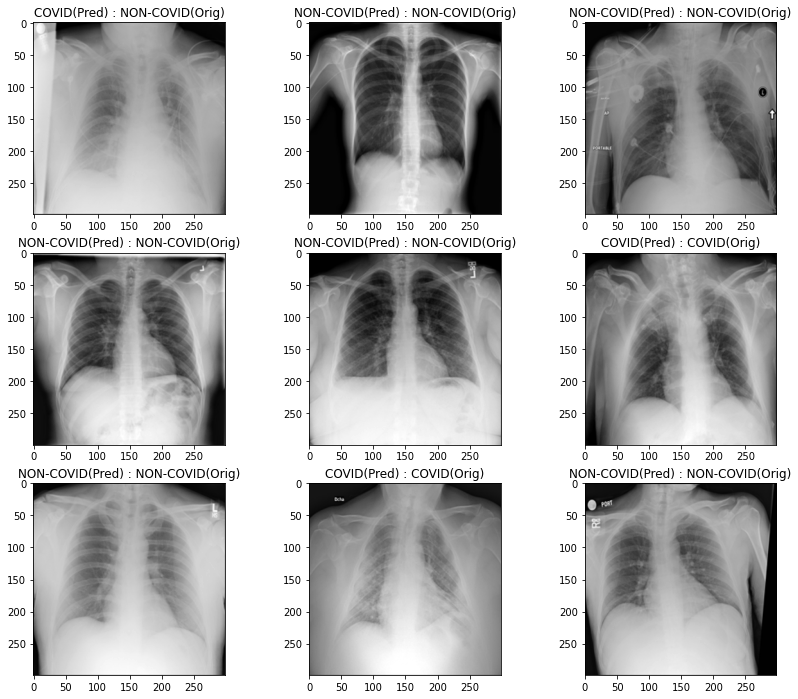

In [179]:
train_object.pred_image_show(random_9_test)

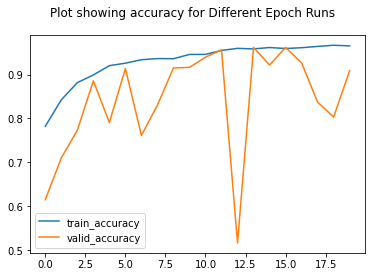

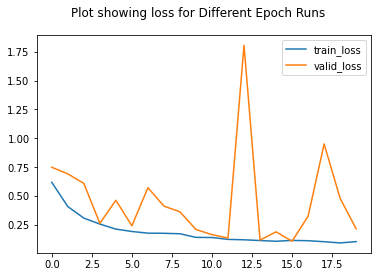

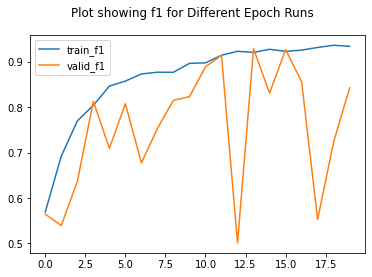

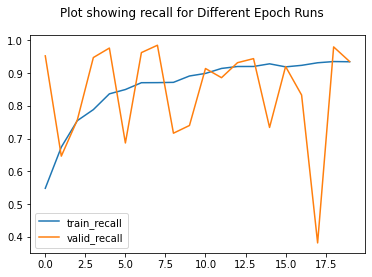

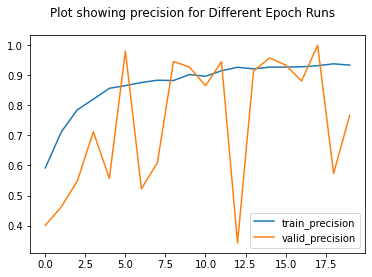

In [184]:
train_object.plot_metrics()

In [185]:
train_dict

{'loss': [0.6163649,
  0.40622935,
  0.30596367,
  0.2543064,
  0.21044083,
  0.18977036,
  0.17544179,
  0.17413282,
  0.17007594,
  0.13879026,
  0.13762118,
  0.12119462,
  0.11778121,
  0.111191116,
  0.10502562,
  0.11229281,
  0.109751865,
  0.101092644,
  0.09063518,
  0.10179024],
 'accuracy': [0.78213805,
  0.8425801,
  0.8817095,
  0.8993009,
  0.9205007,
  0.92613894,
  0.9340325,
  0.9366261,
  0.93628776,
  0.9460983,
  0.9462111,
  0.9552323,
  0.95996845,
  0.958728,
  0.96188545,
  0.95963013,
  0.96143436,
  0.96436626,
  0.9670726,
  0.9656067],
 'f1': [0.5691347011596789,
  0.6922398589065256,
  0.7697036223929747,
  0.8039517014270033,
  0.8463717585530616,
  0.8575157711551012,
  0.8731844786473011,
  0.8770778652668416,
  0.876933130037029,
  0.8966262975778547,
  0.8977491961414792,
  0.9144949386172733,
  0.9232100367726584,
  0.9207105719237435,
  0.9276231263383297,
  0.923076923076923,
  0.92578125,
  0.9316313284292513,
  0.9365493263798348,
  0.934111039101

In [187]:
val_dict

{'loss': [0.7474566,
  0.68975693,
  0.6075159,
  0.2603287,
  0.46113065,
  0.23917319,
  0.56998765,
  0.4100958,
  0.36063644,
  0.2072646,
  0.16242254,
  0.13282734,
  1.80675,
  0.11540195,
  0.18714516,
  0.10505649,
  0.32216457,
  0.94941926,
  0.47740078,
  0.21319279],
 'accuracy': [0.6146298,
  0.71008027,
  0.77297056,
  0.8858162,
  0.7908118,
  0.9139162,
  0.76137376,
  0.8305085,
  0.91525424,
  0.9165923,
  0.9397859,
  0.9567351,
  0.5160571,
  0.9620874,
  0.9219447,
  0.9620874,
  0.92685103,
  0.8371989,
  0.8033006,
  0.9090098],
 'f1': [0.5640766902119072,
  0.5390070921985815,
  0.6361686919228019,
  0.8128654970760234,
  0.7092374457532549,
  0.8075772681954136,
  0.6771273385636692,
  0.7532467532467533,
  0.8151750972762647,
  0.8230842005676443,
  0.8888888888888888,
  0.9145374449339206,
  0.5006902899217672,
  0.9288702928870294,
  0.8309178743961353,
  0.9269131556319863,
  0.856140350877193,
  0.5521472392638037,
  0.7235109717868338,
  0.84259259259259

In [189]:
for metrics in val_dict.keys():
    print(f'Max {metrics} is {max(val_dict[metrics])} at epoch {val_dict[metrics].index(max(val_dict[metrics]))}')

Max loss is 1.8067500591278076 at epoch 12
Max accuracy is 0.9620873928070068 at epoch 13
Max f1 is 0.9288702928870294 at epoch 13
Max precision is 1.0 at epoch 17
Max recall is 0.9847198641765704 at epoch 7
Max ckpt_name is ./content/data/ckpt/ckpt_0.9620874_acc.pt at epoch 5


In [182]:
def serialize_object(pickle_fil, object_ser):
    with open(pickle_fil, 'wb') as f:
        pickle.dump(object_ser, f)

def restore_object(pickle_fil):
    with open(pickle_fil, 'rb') as f:
        newobject = pickle.load(f)
        return newobject

In [192]:
serialize_object('./train_dict.pickle', train_dict)
serialize_object('./val_dict.pickle', val_dict)
train_dict_replica = restore_object('./train_dict.pickle')
val_dict_replica = restore_object('./val_dict.pickle')


In [193]:
train_dict_replica
val_dict_replica

{'loss': [0.7474566,
  0.68975693,
  0.6075159,
  0.2603287,
  0.46113065,
  0.23917319,
  0.56998765,
  0.4100958,
  0.36063644,
  0.2072646,
  0.16242254,
  0.13282734,
  1.80675,
  0.11540195,
  0.18714516,
  0.10505649,
  0.32216457,
  0.94941926,
  0.47740078,
  0.21319279],
 'accuracy': [0.6146298,
  0.71008027,
  0.77297056,
  0.8858162,
  0.7908118,
  0.9139162,
  0.76137376,
  0.8305085,
  0.91525424,
  0.9165923,
  0.9397859,
  0.9567351,
  0.5160571,
  0.9620874,
  0.9219447,
  0.9620874,
  0.92685103,
  0.8371989,
  0.8033006,
  0.9090098],
 'f1': [0.5640766902119072,
  0.5390070921985815,
  0.6361686919228019,
  0.8128654970760234,
  0.7092374457532549,
  0.8075772681954136,
  0.6771273385636692,
  0.7532467532467533,
  0.8151750972762647,
  0.8230842005676443,
  0.8888888888888888,
  0.9145374449339206,
  0.5006902899217672,
  0.9288702928870294,
  0.8309178743961353,
  0.9269131556319863,
  0.856140350877193,
  0.5521472392638037,
  0.7235109717868338,
  0.84259259259259

In [195]:
#Check if both objects are one and same
train_dict == train_dict_replica , val_dict == val_dict_replica

(True, True)

In [201]:
class VGG16_custom_new(tensorflow.keras.Model):
    def __init__(self, input_dim, batch_norm):
        super(VGG16_custom_new, self).__init__()
        
        self.conv_block_1 = Sequential(self.create_conv_block(64, 2, batch_norm))
        self.conv_block_2 = Sequential(self.create_conv_block(128, 2, batch_norm))
        self.conv_block_3 = Sequential(self.create_conv_block(256, 3, batch_norm))
        self.conv_block_4 = Sequential(self.create_conv_block(512, 3, batch_norm))
        self.conv_block_5 = Sequential(self.create_conv_block(512, 3, batch_norm))
        
        self.intermediate = Sequential([
            Flatten(),
            #Dropout(0.01),
            Dense(4096, use_bias=True),
            #BatchNormalization(),
            Activation('relu'),
            Dropout(0.5),
            Dense(4096, use_bias=True),
            #BatchNormalization(),
            Activation('relu'),
            Dropout(0.5)
        ]
        )
    
        self.classifier = Dense(2)
    
    
#############################################################################        
    def create_conv_block(self,out_dim, instances, batch_norm):
        ll = []
        for i in range(instances):
            layer = self.create_layer(out_dim, batch_norm)
            ll.extend(layer)
        maxpool = MaxPool2D((2,2), strides=(2,2))
        ll.append(maxpool)
        return ll
        
    def create_layer(self,out_dim, batch_norm):
        layer_list = []
        if batch_norm:
            flag = False
        else:
            flag = True
        layer = Conv2D(out_dim, (3,3), padding='same', use_bias=flag)
        layer_list.append(layer)
        if batch_norm:
            bn = BatchNormalization()
            layer_list.append(bn)
        activation = Activation('relu')
        layer_list.append(activation)
        return layer_list  

    def call(self, input_dim):
        x = self.conv_block_1(input_dim)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.conv_block_4(x)
        x = self.conv_block_5(x)
        x = self.intermediate(x)
        x = self.classifier(x)

        return x

In [202]:
X_input = Input(shape=(224,224,1,))
out = VGG16_custom_new(224, False)(X_input)
temp_model = Model(inputs=X_input, outputs=out)
temp_model.summary()#expand_nested=True)

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_5 (InputLayer)         [(None, 224, 224, 1)]     0         
_________________________________________________________________
vg_g16_custom_new (VGG16_cus (None, 2)                 134267586 
Total params: 134,267,586
Trainable params: 134,267,586
Non-trainable params: 0
_________________________________________________________________


In [203]:
model_vgg16_new = VGG16_custom_new(224, False)

In [204]:
#model_vgg16.get_layer(0)
for layer in model_vgg16_new.layers:
    for sub_layer in layer.layers:
        config = sub_layer.get_config()
        if config['name'].__contains__('conv2d'):
            print(f'{config["name"]}, {config["filters"]}, {config["kernel_size"]}, {config["strides"]}, {config["padding"]}, {config["use_bias"]}')
        elif config['name'].__contains__('batch_normalization'):
            print(f'{config["name"]}')
        elif config['name'].__contains__('activation'):
            print(f'{config["name"]}, {config["activation"]}')
        elif config['name'].__contains__('max_pooling2d'):
            print(f'{config["name"]}, {config["pool_size"]}, {config["strides"]}')

conv2d_65, 64, (3, 3), (1, 1), same, True
activation_75, relu
conv2d_66, 64, (3, 3), (1, 1), same, True
activation_76, relu
max_pooling2d_25, (2, 2), (2, 2)
conv2d_67, 128, (3, 3), (1, 1), same, True
activation_77, relu
conv2d_68, 128, (3, 3), (1, 1), same, True
activation_78, relu
max_pooling2d_26, (2, 2), (2, 2)
conv2d_69, 256, (3, 3), (1, 1), same, True
activation_79, relu
conv2d_70, 256, (3, 3), (1, 1), same, True
activation_80, relu
conv2d_71, 256, (3, 3), (1, 1), same, True
activation_81, relu
max_pooling2d_27, (2, 2), (2, 2)
conv2d_72, 512, (3, 3), (1, 1), same, True
activation_82, relu
conv2d_73, 512, (3, 3), (1, 1), same, True
activation_83, relu
conv2d_74, 512, (3, 3), (1, 1), same, True
activation_84, relu
max_pooling2d_28, (2, 2), (2, 2)
conv2d_75, 512, (3, 3), (1, 1), same, True
activation_85, relu
conv2d_76, 512, (3, 3), (1, 1), same, True
activation_86, relu
conv2d_77, 512, (3, 3), (1, 1), same, True
activation_87, relu
max_pooling2d_29, (2, 2), (2, 2)
activation_88, rel

AttributeError: 'Dense' object has no attribute 'layers'

In [205]:
opt_new = Adam(learning_rate=0.0001)
loss_fn_new = tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [206]:
train_acc_metric_new = tensorflow.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric_new = tensorflow.keras.metrics.SparseCategoricalAccuracy()
test_acc_metric_new = tensorflow.keras.metrics.SparseCategoricalAccuracy()

In [207]:
os.mkdir('./content/data/ckpt/new')
os.mkdir('./content/data/saved_model/new')

In [208]:
EPOCHS = 20
train_object_new = Model_Train(model_vgg16_new, opt_new, loss_fn_new, EPOCHS, BATCH_SIZE,
                           train_generator, valid_generator, test_generator,
                           train_acc_metric_new, val_acc_metric_new, test_acc_metric_new
                          )

In [209]:
train_object_new.__dict__

{'model': <__main__.VGG16_custom_new at 0x7f4d94dd2f98>,
 'optimizer': <tensorflow.python.keras.optimizer_v2.adam.Adam at 0x7f49e891fa20>,
 'loss_fn': <tensorflow.python.keras.losses.SparseCategoricalCrossentropy at 0x7f49e891f9b0>,
 'epochs': 20,
 'batch_size': 32,
 'train_generator': <__main__.DCMDataFrameIterator at 0x7f4e30288be0>,
 'valid_generator': <__main__.DCMDataFrameIterator at 0x7f4e30288ba8>,
 'test_generator': <__main__.DCMDataFrameIterator at 0x7f4e30288e80>,
 'steps_train': 277,
 'steps_valid': 70,
 'steps_test': 87,
 'train_acc_metric': <tensorflow.python.keras.metrics.SparseCategoricalAccuracy at 0x7f49e891fd68>,
 'val_acc_metric': <tensorflow.python.keras.metrics.SparseCategoricalAccuracy at 0x7f49e891f438>,
 'test_acc_metric': <tensorflow.python.keras.metrics.SparseCategoricalAccuracy at 0x7f49e891f240>,
 'train_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'precision': [],
  'recall': []},
 'valid_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'pre

In [210]:
train_dict_new, val_dict_new = train_object_new.train_validate_loop()

Training Confusion Matrix 
 [[6432  114]
 [2095  227]]
Validation Confusion Matrix 
 [[1643   12]
 [ 480  107]]
Epoch : 0, Train Loss: 0.5102249979972839, Train Accuracy: 0.7509021162986755, Validation Loss: 0.4422401189804077, Validation Accuracy: 0.7805531024932861
Time taken: 192.5088
Training Confusion Matrix 
 [[5996  537]
 [1142 1193]]
Validation Confusion Matrix 
 [[1562   94]
 [ 177  409]]
Epoch : 1, Train Loss: 0.41291818022727966, Train Accuracy: 0.8106675744056702, Validation Loss: 0.30223777890205383, Validation Accuracy: 0.8791257739067078
Time taken: 188.6504
Training Confusion Matrix 
 [[5927  574]
 [ 893 1474]]
Validation Confusion Matrix 
 [[1627   29]
 [ 237  349]]
Epoch : 2, Train Loss: 0.36125287413597107, Train Accuracy: 0.8345737457275391, Validation Loss: 0.2802017629146576, Validation Accuracy: 0.8813559412956238
Time taken: 185.8137
Training Confusion Matrix 
 [[6100  431]
 [ 739 1598]]
Validation Confusion Matrix 
 [[1581   73]
 [ 117  471]]
Epoch : 3, Train L

In [211]:
df_new, loss_new, accuracy_new = train_object_new.get_test_accuracy()

In [212]:
accuracy_new

0.9749463

In [213]:
confusion_matrix(df_new['orig_label'], df_new['pred_label'])

array([[2051,   14],
       [  56,  673]])

In [215]:
train_object_new.predict_single(test_df.iloc[-2,0])

Predicted label for image supplied is : COVID


'COVID'

In [216]:
train_object_new.predict_single(test_df.iloc[-1,0])

Predicted label for image supplied is : NON-COVID


'NON-COVID'

In [217]:
train_object_new.model.save_weights('./content/data/ckpt/model_new_best_weights')

In [218]:
random_9_test = random.sample(list(test_df.values), 9)
random_9_test, len(random_9_test)

([array(['./content/data/DCM/NON_COVID/Normal-8867.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-7298.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-4044.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-9907.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-949.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-1968.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-9364.dcm', '0'], dtype=object),
  array(['./content/data/DCM/COVID/COVID-802.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-3901.dcm', '0'], dtype=object)],
 9)

In [219]:
random_9_test[0][0], random_9_test[0][1]

('./content/data/DCM/NON_COVID/Normal-8867.dcm', '0')

Image path is ./content/data/DCM/NON_COVID/Normal-8867.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-7298.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-4044.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-9907.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-949.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-1968.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-9364.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is 

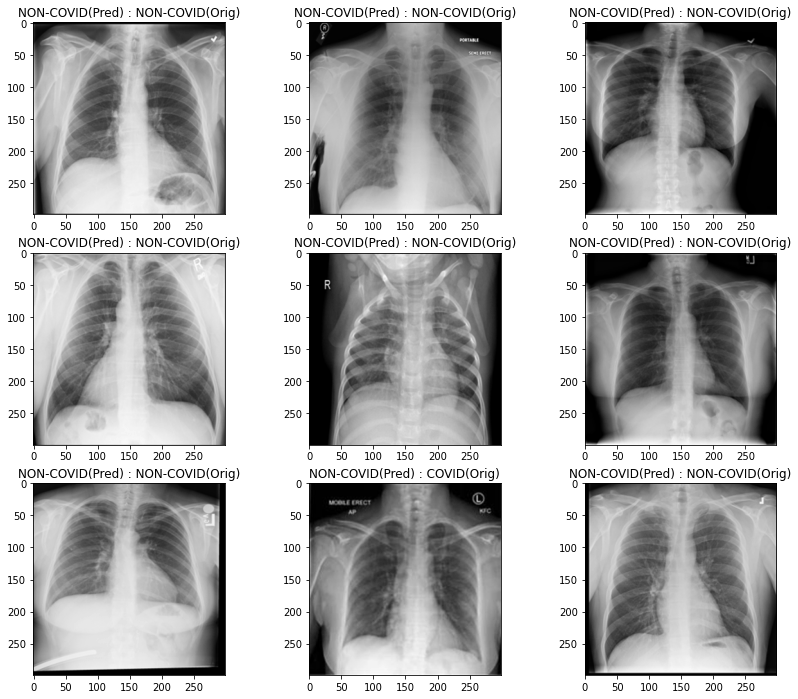

In [220]:
train_object_new.pred_image_show(random_9_test)

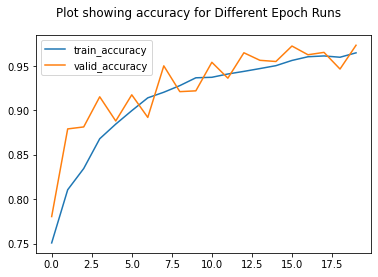

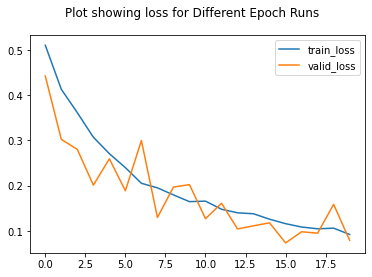

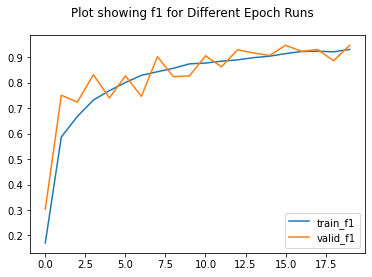

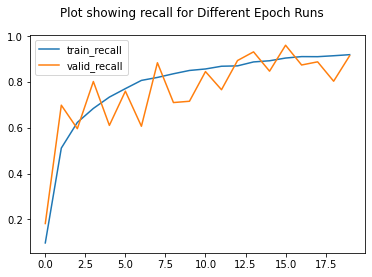

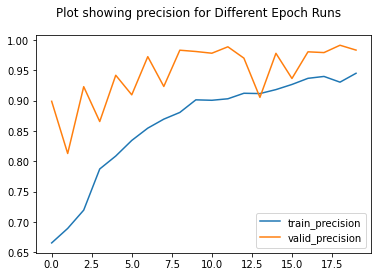

In [221]:
train_object_new.plot_metrics()

In [222]:
for metrics in val_dict_new.keys():
    print(f'Max {metrics} is {max(val_dict_new[metrics])} at epoch {val_dict_new[metrics].index(max(val_dict_new[metrics]))}')

Max loss is 0.4422401189804077 at epoch 0
Max accuracy is 0.9732381701469421 at epoch 19
Max f1 is 0.9478114478114477 at epoch 15
Max precision is 0.991578947368421 at epoch 18
Max recall is 0.959114139693356 at epoch 15
Max ckpt_name is ./content/data/ckpt/ckpt_0.97323817_acc.pt at epoch 6


In [224]:
serialize_object('./train_dict_new.pickle', train_dict_new)
serialize_object('./val_dict_new.pickle', val_dict_new)
train_dict_new_replica = restore_object('./train_dict_new.pickle')
val_dict_new_replica = restore_object('./val_dict_new.pickle')

#Check if both objects are one and same
train_dict_new == train_dict_new_replica , val_dict_new == val_dict_new_replica

(True, True)

In [225]:
tensorflow.__version__

'2.2.0'

In [227]:
!more ./content/data/ckpt/checkpoint

model_checkpoint_path: "model_new_best_weights"
all_model_checkpoint_paths: "model_new_best_weights"


In [228]:
with zipfile.ZipFile('./model_new_best_weights.zip', 'w') as myzip: ## filenames
    myzip.write('./content/data/ckpt/checkpoint')
    myzip.write('./content/data/ckpt/model_new_best_weights.data-00000-of-00002')
    myzip.write('./content/data/ckpt/model_new_best_weights.data-00001-of-00002')
    myzip.write('./content/data/ckpt/model_new_best_weights.index')

In [233]:
!tar cvf ./model_new_best_weights.tar ./content/data/ckpt/


./content/data/ckpt/
./content/data/ckpt/ckpt_0.97323817_acc.pt.index
./content/data/ckpt/ckpt_0.91525424_acc.pt.index
./content/data/ckpt/model_new_best_weights.data-00001-of-00002
./content/data/ckpt/model_new_best_weights.data-00000-of-00002
./content/data/ckpt/ckpt_0.9174844_acc.pt.index
./content/data/ckpt/ckpt_0.95004463_acc.pt.data-00001-of-00002
./content/data/ckpt/checkpoint
./content/data/ckpt/ckpt_0.9540589_acc.pt.data-00000-of-00002
./content/data/ckpt/ckpt_0.9723461_acc.pt.index
./content/data/ckpt/ckpt_0.9540589_acc.pt.data-00001-of-00002
./content/data/ckpt/.ipynb_checkpoints/
./content/data/ckpt/ckpt_0.9540589_acc.pt.index
./content/data/ckpt/ckpt_0.9723461_acc.pt.data-00000-of-00002
./content/data/ckpt/ckpt_0.9723461_acc.pt.data-00001-of-00002
./content/data/ckpt/ckpt_0.91525424_acc.pt.data-00001-of-00002
./content/data/ckpt/ckpt_0.95004463_acc.pt.data-00000-of-00002
./content/data/ckpt/ckpt_0.9647636_acc.pt.index
./content/data/ckpt/new/
./content/data/ckpt/ckpt_0.917